# 01. EDA — ESS 배터리 수명 예측

- 데이터: MIT-Stanford (Severson et al., Nature Energy 2019)
- Batch1 = Train, Batch2 = Test, Batch3 = 추가 Test
- EOL 기준: SOH 80% (방전용량 1.1Ah × 0.8 = 0.88Ah)

## 0. 환경 설정

In [47]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mat73
import scipy.io as sio

plt.rcParams['font.family'] = 'AppleGothic'   # 한글 폰트 (macOS)
plt.rcParams['axes.unicode_minus'] = False

# 노트북 위치(notebooks/) 기준 경로
ROOT = Path.cwd().parent
DATA_DIR = ROOT / 'data' / 'raw'
PROC_DIR = ROOT / 'data' / 'processed'
FIG_DIR  = ROOT / 'results' / 'figures'
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

BATCH_FILES = {
    'b1': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',  # train
    'b2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat',  # test
    'b3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat',  # 추가 test
}
NOMINAL = 1.1          # 정격 용량 (Ah)
EOL = NOMINAL * 0.8    # 0.88 Ah

print('cwd:', Path.cwd())
print('raw 파일:', [p.name for p in DATA_DIR.glob('*.mat')])

cwd: /Users/byunhyunjun/workspace/data-analytics-project/ess-battery-life-prediction/notebooks
raw 파일: ['2018-02-20_batchdata_updated_struct_errorcorrect.mat', '2017-05-12_batchdata_updated_struct_errorcorrect.mat', '2018-04-12_batchdata_updated_struct_errorcorrect.mat']


## 1. 데이터 로딩 함수

- `.mat`이 MATLAB v7.3(HDF5) 형식이라 `mat73`으로 읽고, 실패하면 `scipy`로 다시 시도
- `ERROR:root: MATLAB type not supported: string` 로그는 무시해도 됨 (barcode, channel_id만 None)

In [48]:
def load_mat(path):
    try:
        return mat73.loadmat(path)
    except Exception:
        return sio.loadmat(path, simplify_cells=True)

def to_list_of_dicts(batch):
    """mat73 결과 {key: [셀1, 셀2, ...]} → [{셀1}, {셀2}, ...]"""
    if isinstance(batch, dict):
        keys = list(batch.keys())
        n = len(batch[keys[0]])
        return [{k: batch[k][i] for k in keys} for i in range(n)]
    return batch

def load_batch(name):
    mat = load_mat(DATA_DIR / BATCH_FILES[name])
    return to_list_of_dicts(mat['batch'])

def scalar(x):
    return float(np.ravel(x)[0]) if np.size(x) else np.nan

def extract_summary(batch, batch_name):
    """셀별 summary(사이클 단위 요약)를 하나의 DataFrame으로"""
    rows = []
    for i, cell in enumerate(batch):
        s = cell['summary']
        df = pd.DataFrame({k: np.ravel(v) for k, v in s.items()})
        df['cell_id'] = f'{batch_name}_c{i:02d}'
        df['policy'] = cell.get('policy_readable')
        df['cycle_life'] = scalar(cell['cycle_life'])
        rows.append(df)
    return pd.concat(rows, ignore_index=True)

## 2. Batch1 로드 (처음 1회만, 수십 초 소요)

결과는 `data/processed/`에 pickle로 저장해서 다음부터는 바로 읽는다.

In [49]:
cache = PROC_DIR / 'batch1_summary.pkl'

if cache.exists():
    df1 = pd.read_pickle(cache)
else:
    batch1 = load_batch('b1')
    print('셀 개수:', len(batch1))            # 46이면 정상
    print('셀 keys:', list(batch1[0].keys()))
    df1 = extract_summary(batch1, 'b1')
    df1.to_pickle(cache)

print(df1.shape)   # 대략 (38811, 11) 근처면 정상
df1.head()

(38811, 11)


,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime,cycle,cell_id,policy,cycle_life
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,b1_c00,3.6C(80%)-3.6C,1190.0
1,0.016742,1.071042,1.070689,31.875011,35.652016,29.566130,13.341250,2.0,b1_c00,3.6C(80%)-3.6C,1190.0
2,0.016724,1.071674,1.071900,31.931490,35.692978,29.604385,13.425777,3.0,b1_c00,3.6C(80%)-3.6C,1190.0
3,0.016681,1.072304,1.072510,31.932603,35.680588,29.744202,13.425167,4.0,b1_c00,3.6C(80%)-3.6C,1190.0
4,0.016662,1.072970,1.073174,31.959322,35.728691,29.644709,13.341442,5.0,b1_c00,3.6C(80%)-3.6C,1190.0


## 3. 기본 확인

In [50]:
df1.info()
df1.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 38811 entries, 0 to 38810
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   IR          38811 non-null  float64
 1   QCharge     38811 non-null  float64
 2   QDischarge  38811 non-null  float64
 3   Tavg        38811 non-null  float64
 4   Tmax        38811 non-null  float64
 5   Tmin        38811 non-null  float64
 6   chargetime  38811 non-null  float64
 7   cycle       38811 non-null  float64
 8   cell_id     38811 non-null  str    
 9   policy      38811 non-null  str    
 10  cycle_life  38811 non-null  float64
dtypes: float64(9), str(2)
memory usage: 3.3 MB


,count,mean,std,min,25%,50%,75%,max
IR,38811.0,0.016957,0.001008,0.0,0.016550,0.016891,0.017292,0.021789
QCharge,38811.0,1.045334,0.060979,0.0,1.035822,1.062450,1.076131,2.965895
QDischarge,38811.0,1.045058,0.059039,0.0,1.036104,1.062685,1.076416,2.884085
Tavg,38811.0,33.403617,1.964222,0.0,32.438187,33.470675,34.472057,38.413597
Tmax,38811.0,37.321636,2.760068,0.0,35.961458,37.598900,39.107354,43.419384
Tmin,38811.0,30.588524,1.574691,0.0,29.937651,30.390041,31.200084,34.850979
chargetime,38811.0,11.510206,4.517705,0.0,10.652681,11.208358,12.092287,419.873355
cycle,38811.0,442.120584,276.875520,1.0,211.000000,422.000000,640.000000,1226.000000
cycle_life,38811.0,884.241169,186.940217,534.0,731.000000,870.000000,1017.000000,1227.000000


In [51]:
cell_info = df1.groupby('cell_id').agg(cycle_life=('cycle_life','first'),
                                       policy=('policy','first'),
                                       n_cycles=('cycle','max'))
print('셀 수:', len(cell_info), '/ 정책 수:', cell_info['policy'].nunique())
cell_info.sort_values('cycle_life').head(10)

셀 수: 46 / 정책 수: 23


,cycle_life,policy,n_cycles
cell_id,,,
b1_c20,534.0,5.4C(80%)-5.4C,533.0
b1_c21,559.0,5.4C(80%)-5.4C,558.0
b1_c45,599.0,8C(35%)-3.6C,598.0
b1_c44,616.0,8C(35%)-3.6C,615.0
b1_c38,617.0,7C(40%)-3.6C,616.0
b1_c39,625.0,7C(40%)-3.6C,624.0
b1_c06,636.0,4.8C(80%)-4.8C,635.0
b1_c37,648.0,7C(40%)-3C,647.0
b1_c43,651.0,8C(25%)-3.6C,650.0


## 4. 수명(cycle_life) 분포

- 분류 과제 기준선: 550 사이클

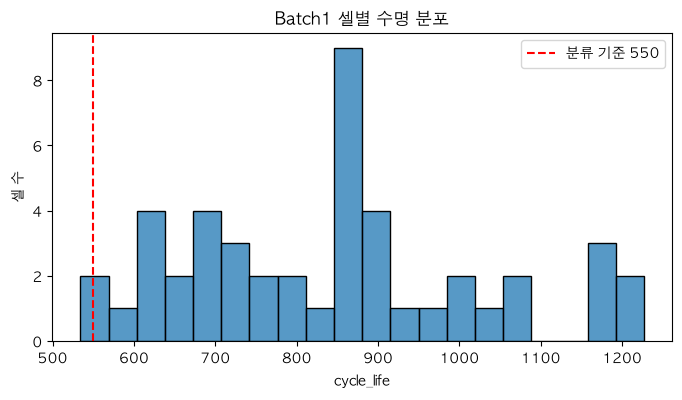

500 이상 비율: 0.022
1000 이상 비율: 0.217


In [52]:
fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(cell_info['cycle_life'], bins=20, ax=ax)
ax.axvline(550, color='r', ls='--', label='분류 기준 550')
ax.set(title='Batch1 셀별 수명 분포', xlabel='cycle_life', ylabel='셀 수')
ax.legend()
fig.savefig(FIG_DIR / 'b1_cycle_life_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print('500 이상 비율:', (cell_info['cycle_life'] <= 550).mean().round(3))
print('1000 이상 비율:', (cell_info['cycle_life'] >= 1000).mean().round(3))

**해석:** (그래프 확인 후 작성) 
**시사점:** 

## 5. 사이클별 방전용량(QD) 열화 곡선

- 이상치 제거: 정격의 0.8~1.2배 범위만 사용 (강사 노트북 기준)

제거된 행: 48


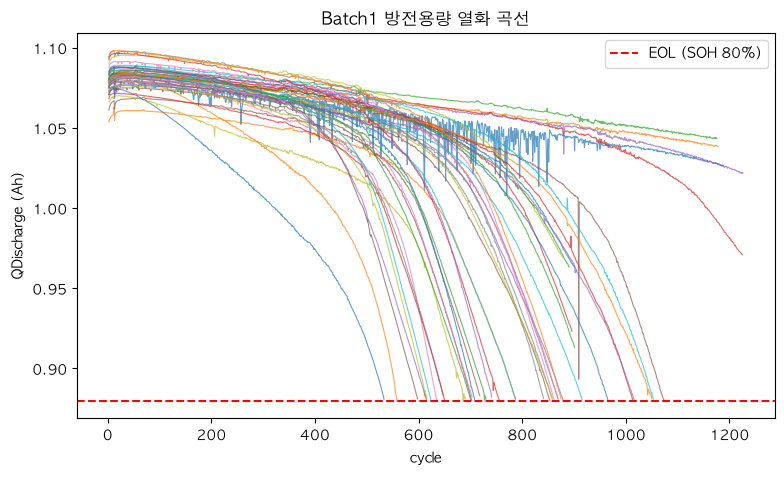

In [53]:
df1_clean = df1[(df1['QDischarge'] > NOMINAL*0.8) & (df1['QDischarge'] < NOMINAL*1.2)]
print('제거된 행:', len(df1) - len(df1_clean))

fig, ax = plt.subplots(figsize=(9,5))
for cid, g in df1_clean.groupby('cell_id'):
    ax.plot(g['cycle'], g['QDischarge'], lw=0.8, alpha=0.7)
ax.axhline(EOL, color='r', ls='--', label='EOL (SOH 80%)')
ax.set(title='Batch1 방전용량 열화 곡선', xlabel='cycle', ylabel='QDischarge (Ah)')
ax.legend()
fig.savefig(FIG_DIR / 'b1_qd_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**해석:** 

**시사점:** 

## 6. 초기 100사이클 vs 수명 — 조기 예측 가능성 확인

In [54]:
early = df1_clean[df1_clean['cycle'] <= 100]
feat = early.groupby('cell_id').agg(QD_c2=('QDischarge', lambda s: s.iloc[1] if len(s)>1 else np.nan),
                                    QD_c100=('QDischarge','last'),
                                    IR_mean=('IR','mean'),
                                    Tmax_mean=('Tmax','mean'),
                                    chargetime_mean=('chargetime','mean'))
feat['QD_diff'] = feat['QD_c100'] - feat['QD_c2']
feat = feat.join(cell_info['cycle_life'])
feat.corr()['cycle_life'].sort_values()

Tmax_mean         -0.403556
QD_c2              0.079570
IR_mean            0.175862
QD_c100            0.295098
QD_diff            0.557864
chargetime_mean    0.577045
cycle_life         1.000000
Name: cycle_life, dtype: float64

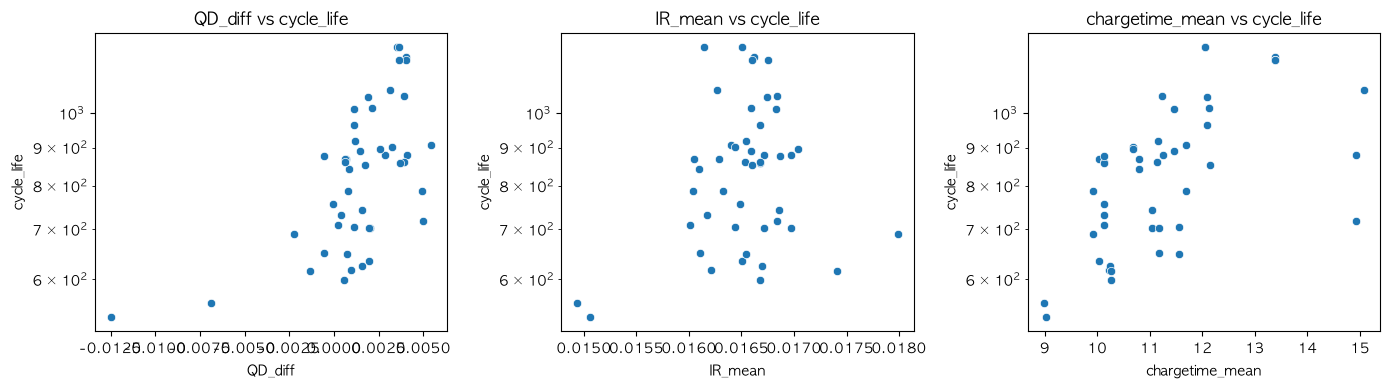

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, col in zip(axes, ['QD_diff','IR_mean','chargetime_mean']):
    sns.scatterplot(data=feat, x=col, y='cycle_life', ax=ax)
    ax.set_yscale('log')
    ax.set_title(f'{col} vs cycle_life')
fig.tight_layout()
fig.savefig(FIG_DIR / 'b1_early_feat_vs_life.png', dpi=150, bbox_inches='tight')
plt.show()

**해석:** 

**시사점 → 전략 연결:** 

In [56]:
min_qd = df1[df1['QDischarge'] > 0.5].groupby('cell_id')['QDischarge'].min()
check = cell_info.join(min_qd.rename('min_QD'))
check['gap_to_EOL'] = check['min_QD'] - EOL   # 0에 가까울수록 EOL 도달

print(check['min_QD'].describe().round(4))
check.sort_values('min_QD', ascending=False).head(10)

count    46.0000
mean      0.9027
std       0.0465
min       0.8801
25%       0.8804
50%       0.8810
75%       0.8832
max       1.0433
Name: min_QD, dtype: float64


,cycle_life,policy,n_cycles,min_QD,gap_to_EOL
cell_id,,,,,
b1_c02,1177.0,3.6C(80%)-3.6C,1176.0,1.043279,0.163279
b1_c01,1179.0,3.6C(80%)-3.6C,1178.0,1.038225,0.158225
b1_c04,1227.0,4C(80%)-4C,1226.0,1.021641,0.141641
b1_c00,1190.0,3.6C(80%)-3.6C,1189.0,1.008352,0.128352
b1_c03,1226.0,4C(80%)-4C,1225.0,0.970921,0.090921
b1_c08,879.0,5.4C(40%)-3.6C,878.0,0.969025,0.089025
b1_c22,891.0,6C(30%)-3.6C,890.0,0.963279,0.083279
b1_c10,906.0,5.4C(50%)-3C,905.0,0.961019,0.081019
b1_c13,897.0,5.4C(50%)-3.6C,896.0,0.923136,0.043136


## 7. EDA 요약 (DAY1 설계서용)

| # | 관찰 | 근거 그래프 | 모델링 전략 반영 |
|---|---|---|---|
| 1 |  |  |  |
| 2 |  |  |  |
| 3 |  |  |  |

In [57]:
import gc

def summarize_batch(name):
    cache = PROC_DIR / f'batch{name[-1]}_summary.pkl'
    if cache.exists():
        return pd.read_pickle(cache)
    batch = load_batch(name)
    df = extract_summary(batch, name)
    df.to_pickle(cache)
    del batch; gc.collect()          # 원본 데이터는 메모리에서 해제
    return df

def batch_report(df, name):
    d = df[df['QDischarge'] > 0.5]
    info = d.groupby('cell_id').agg(cycle_life=('cycle_life', 'first'),
                                    policy=('policy', 'first'),
                                    first_QD=('QDischarge', lambda s: s.iloc[1] if len(s) > 1 else np.nan),
                                    min_QD=('QDischarge', 'min'))
    info['censored'] = info['min_QD'] > 0.89
    print(f'=== {name} ===')
    print('셀 수:', len(info), '| 수명 범위:', info['cycle_life'].min(), '~', info['cycle_life'].max())
    print('550 미만:', (info['cycle_life'] < 550).sum(), '개')
    print('EOL 미도달:', info['censored'].sum(), '개')
    return info

df2 = summarize_batch('b2'); info2 = batch_report(df2, 'Batch2')
df3 = summarize_batch('b3'); info3 = batch_report(df3, 'Batch3')

# Batch1 A그룹의 연장 의심 셀: 첫 용량이 1.0 근처면 새 셀이 아니라 이어서 측정한 셀
info2.loc[[f'b2_c{i:02d}' for i in [7, 8, 9, 15, 16]]]

=== Batch2 ===
셀 수: 47 | 수명 범위: 392.0 ~ 1186.0
550 미만: 30 개
EOL 미도달: 4 개
=== Batch3 ===
셀 수: 46 | 수명 범위: 541.0 ~ 1935.0
550 미만: 1 개
EOL 미도달: 2 개


,cycle_life,policy,first_QD,min_QD,censored
cell_id,,,,,
b2_c07,777.0,4.8C(80%)-4.8C-newstructure,1.090478,0.826481,False
b2_c08,904.0,5.2C(58%)-4C-newstructure,1.090633,0.825586,False
b2_c09,791.0,5.6C(26%)-4.5C-newstructure,1.094971,0.826105,False
b2_c15,396.0,3.6C(9%)-5C,1.069749,0.826088,False
b2_c16,472.0,4.8C(80%)-4.8C,1.094536,0.826489,False


In [58]:
cont = [f'b2_c{i:02d}' for i in [7, 8, 9, 15, 16]]
display(info2.loc[cont])                              # 이어진 셀 확인
display(info2[info2['censored']])                     # Batch2 EOL 미도달 4개
clean2 = info2.drop(cont).query('~censored')
print('정리 후 Batch2:', len(clean2), '셀 | 550 미만:', (clean2['cycle_life'] < 550).sum())

,cycle_life,policy,first_QD,min_QD,censored
cell_id,,,,,
b2_c07,777.0,4.8C(80%)-4.8C-newstructure,1.090478,0.826481,False
b2_c08,904.0,5.2C(58%)-4C-newstructure,1.090633,0.825586,False
b2_c09,791.0,5.6C(26%)-4.5C-newstructure,1.094971,0.826105,False
b2_c15,396.0,3.6C(9%)-5C,1.069749,0.826088,False
b2_c16,472.0,4.8C(80%)-4.8C,1.094536,0.826489,False


,cycle_life,policy,first_QD,min_QD,censored
cell_id,,,,,
b2_c22,NaN,VarCharge-2C-100cycles,1.091319,0.989696,True
b2_c23,NaN,VarCharge-4C-100cycles,1.090460,0.931362,True
b2_c37,NaN,3.6C(80%)-3.6C(SLOWCYCLE,1.083419,0.998693,True
b2_c38,NaN,4.8C(80%)-4.8C(SLOWCYCLE,1.084366,1.074498,True


정리 후 Batch2: 38 셀 | 550 미만: 28


In [59]:
info2[info2['policy'].str.contains(r'^3\.6C\(80%\)-3\.6C$|^4C\(80%\)-4C$', regex=True)]

,cycle_life,policy,first_QD,min_QD,censored
cell_id,,,,,


In [60]:
display(info3[info3['censored']])

,cycle_life,policy,first_QD,min_QD,censored
cell_id,,,,,
b3_c23,NaN,4.8C(80%)-4.8C-newstructure,1.066155,0.937011,True
b3_c32,NaN,4.8C(80%)-4.8C-newstructure,1.072586,0.973883,True


# Part 2. 핵심 질문 5가지 (정리된 데이터 기준)

- 입력: `data/processed/` (`src/preprocess.py`, `src/features.py` 결과)
- 셀 수: Batch1 36 / Batch2 39 / Batch3 44 (미완료·특수 실험 셀 제거 후)

In [61]:
import sys, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
PROC_DIR = ROOT / 'data' / 'processed'
FIG_DIR = ROOT / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
NOMINAL, EOL = 1.1, 0.88
BATCHES = ['b1', 'b2', 'b3']
BATCH_LABEL = {'b1': 'Batch1 (Train)', 'b2': 'Batch2 (Test)', 'b3': 'Batch3 (추가 Test)'}

summ  = {b: pd.read_pickle(PROC_DIR / f'{b}_summary_clean.pkl') for b in BATCHES}
qdlin = {b: pd.read_pickle(PROC_DIR / f'{b}_qdlin.pkl') for b in BATCHES}
feat  = pd.concat([pd.read_csv(PROC_DIR / f'features_{b}.csv', index_col=0) for b in BATCHES])

# 충전 정책 파싱: "5.4C(40%)-3.6C" → 1단계 C-rate 5.4, 전환 SOC 40%, 2단계 C-rate 3.6
pol = feat['policy'].str.extract(r'^([\d.]+)C\((\d+)%\)-([\d.]+)C')
feat['C1'] = pol[0].astype(float)
feat['switch_soc'] = pol[1].astype(float)
feat['C2'] = pol[2].astype(float)
feat['newstructure'] = feat['policy'].str.contains('newstructure')
print(feat.groupby('batch').size())

batch
b1    36
b2    39
b3    44
dtype: int64


## Q1. Cycle Life 분포는 어떻게 생겼는가?

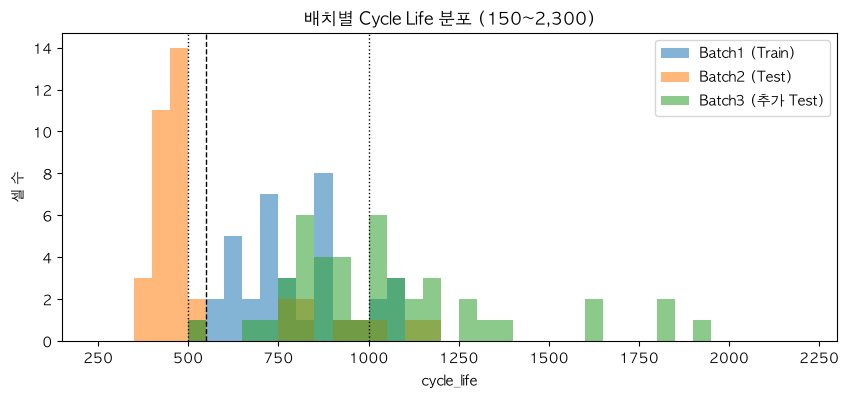

,n,min,median,max,long_gt1000,short_lt500,short_lt550
batch,,,,,,,
b1,36,534.0,772.5,1074.0,0.139,0.000,0.028
b2,39,392.0,472.0,1186.0,0.077,0.718,0.769
b3,44,541.0,1005.5,1935.0,0.523,0.000,0.023


In [62]:
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.arange(150, 2350, 50)
for b in BATCHES:
    ax.hist(feat.loc[feat['batch'] == b, 'cycle_life'], bins=bins, alpha=0.55, label=BATCH_LABEL[b])
for x, ls in [(500, ':'), (550, '--'), (1000, ':')]:
    ax.axvline(x, color='k', ls=ls, lw=1)
ax.set(title='배치별 Cycle Life 분포 (150~2,300)', xlabel='cycle_life', ylabel='셀 수', xlim=(150, 2300))
ax.legend()
fig.savefig(FIG_DIR / 'q1_cycle_life_hist.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = feat.groupby('batch')['cycle_life'].agg(
    n='size', min='min', median='median', max='max',
    long_gt1000=lambda s: (s > 1000).mean(),
    short_lt500=lambda s: (s < 500).mean(),
    short_lt550=lambda s: (s < 550).mean())
ratio.round(3)

In [63]:
# 이상치 셀: 배치 안에서 log(수명) 기준 IQR 1.5배 밖 + 배치별 최단수명 3개
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return (s < q1 - 1.5 * (q3 - q1)) | (s > q3 + 1.5 * (q3 - q1))

feat['life_outlier'] = feat.groupby('batch')['log_cycle_life'].transform(iqr_outliers)
cols = ['batch', 'cycle_life', 'policy', 'C1', 'chargetime_mean_5', 'dQ_log_var']
print('IQR 이상치:')
display(feat[feat['life_outlier']][cols])
print('배치별 최단수명 3개:')
display(feat.sort_values('cycle_life').groupby('batch').head(3).sort_values(['batch', 'cycle_life'])[cols])
print('배치별 중앙값 (비교용):')
feat.groupby('batch')[['cycle_life', 'C1', 'chargetime_mean_5', 'dQ_log_var']].median().round(3)

IQR 이상치:


,batch,cycle_life,policy,C1,chargetime_mean_5,dQ_log_var
cell_id,,,,,,
b2_c07,b2,777.0,4.8C(80%)-4.8C-newstructure,4.8,10.036668,-4.436969
b2_c08,b2,904.0,5.2C(58%)-4C-newstructure,5.2,10.039683,-4.048784
b2_c09,b2,791.0,5.6C(26%)-4.5C-newstructure,5.6,10.040518,-4.074234
b2_c32,b2,809.0,4.8C(80%)-4.8C-newstructure,4.8,10.041733,-4.102907
b2_c33,b2,1140.0,5.2C(58%)-4C-newstructure,5.2,10.039380,-4.278158
b2_c34,b2,1186.0,5.6C(26%)-4.5C-newstructure,5.6,10.039870,-4.442689
b2_c43,b2,1029.0,4.8C(80%)-4.8C-newstructure,4.8,10.036313,-4.298838
b2_c44,b2,841.0,5.2C(58%)-4C-newstructure,5.2,10.040485,-4.373032
b2_c45,b2,997.0,5.6C(26%)-4.5C-newstructure,5.6,10.040134,-4.264289


배치별 최단수명 3개:


,batch,cycle_life,policy,C1,chargetime_mean_5,dQ_log_var
cell_id,,,,,,
b1_c20,b1,534.0,5.4C(80%)-5.4C,5.4,9.008858,-3.363507
b1_c21,b1,559.0,5.4C(80%)-5.4C,5.4,8.981738,-3.342297
b1_c45,b1,599.0,8C(35%)-3.6C,8.0,10.242064,-3.423197
b2_c19,b2,392.0,6C(60%)-3C,6.0,10.175164,-3.292164
b2_c06,b2,393.0,3.6C(9%)-5C,3.6,10.178854,-3.682411
b2_c15,b2,396.0,3.6C(9%)-5C,3.6,10.173891,-3.417112
b3_c28,b3,541.0,3.7C(31%)-5.9C-newstructure,3.7,10.060723,-3.441342
b3_c06,b3,667.0,3.7C(31%)-5.9C-newstructure,3.7,10.064076,-3.516391
b3_c31,b3,731.0,5.9C(60%)-3.1C-newstructure,5.9,10.046283,-3.823472


배치별 중앙값 (비교용):


,cycle_life,C1,chargetime_mean_5,dQ_log_var
batch,,,,
b1,772.5,6.0,10.785,-3.774
b2,472.0,5.2,10.174,-3.493
b3,1005.5,5.3,10.044,-4.152


**해석 (초안 — 그래프를 보고 본인 말로 다듬을 것):**
- 배치별 분포가 크게 다르다. 중앙값 Batch1 772 / Batch2 472 / Batch3 1,006
- 단수명(<500) 비율: Batch1 0% / **Batch2 72%** / Batch3 0%, 장수명(>1000) 비율: 14% / 8% / **52%**
- Batch1 최단수명 셀(c20, c21)은 `5.4C(80%)-5.4C`로 초기 충전시간이 9.0분(배치 최단) → 급속충전 영향
- Batch2 IQR 이상치는 오히려 **장수명** 쪽이며 전부 `newstructure` 셀 → 같은 Batch2 안에서도 newstructure 여부로 수명이 갈림 (일반 30셀: 392~514, newstructure 9셀: 777~1,186)

**시사점:**
- Train(534~1,074) 범위 밖의 Test 셀이 많음 → 트리 모델만으로는 외삽 불가, 선형 모델(ElasticNet) 필요
- 수명 범위가 4배 이상 차이 → log(수명)을 타깃으로 사용

## Q2. 열화 곡선 — 방전 용량이 어떻게 감소하는가?

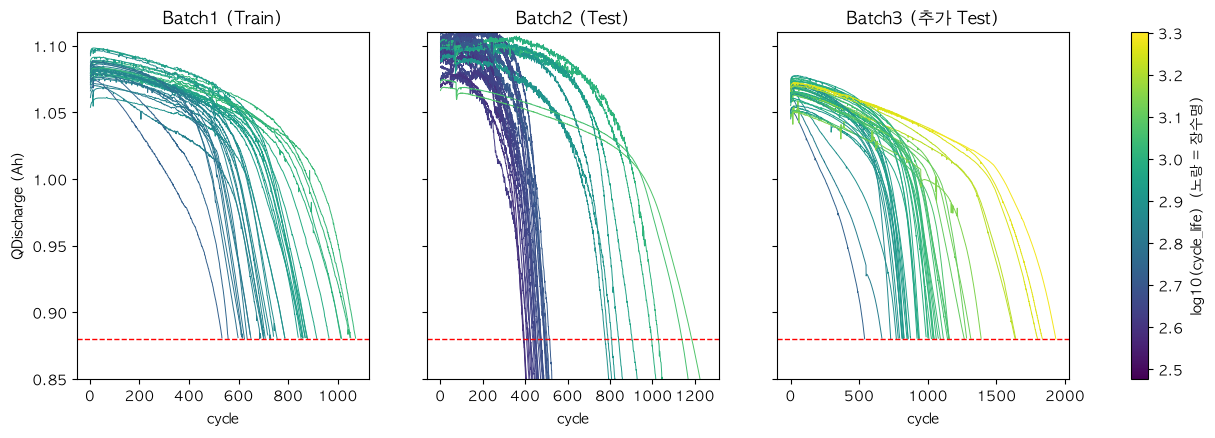

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
norm = plt.Normalize(np.log10(300), np.log10(2000))
for ax, b in zip(axes, BATCHES):
    for cid, g in summ[b].groupby('cell_id'):
        ax.plot(g['cycle'], g['QDischarge'], lw=0.7,
                color=plt.cm.viridis(norm(np.log10(g['cycle_life'].iloc[0]))))
    ax.axhline(EOL, color='r', ls='--', lw=1)
    ax.set(title=BATCH_LABEL[b], xlabel='cycle', ylim=(0.85, 1.11))
axes[0].set_ylabel('QDischarge (Ah)')
sm = plt.cm.ScalarMappable(norm=norm, cmap='viridis')
fig.colorbar(sm, ax=axes, label='log10(cycle_life)  (노랑 = 장수명)')
fig.savefig(FIG_DIR / 'q2_qd_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()

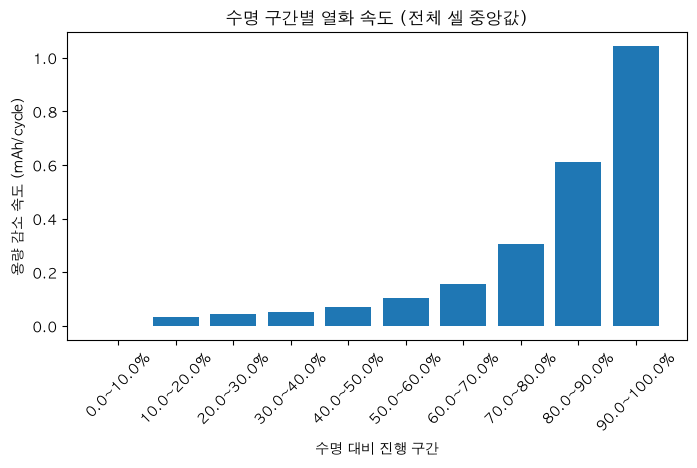

후반(90~100%) / 초반(10~20%) 속도 비율 중앙값: 20.8


In [65]:
# 열화 속도: 수명을 10구간으로 나눠 구간별 용량 감소 속도(Ah/cycle) 비교
def rate_profile(g, n_bins=10):
    g = g.sort_values('cycle')
    life = g['cycle_life'].iloc[0]
    g = g.assign(frac=g['cycle'] / life)
    g['bin'] = pd.cut(g['frac'], np.linspace(0, 1, n_bins + 1), labels=False)
    out = {}
    for k, gg in g.groupby('bin'):
        if len(gg) >= 5:
            out[k] = -np.polyfit(gg['cycle'], gg['QDischarge'], 1)[0]   # 양수 = 감소 속도
    return pd.Series(out)

prof = pd.concat({cid: rate_profile(g) for b in BATCHES for cid, g in summ[b].groupby('cell_id')}, axis=1).T
prof.index.name = 'cell_id'
med = prof.median() * 1000
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f'{i*10}~{i*10+10}%' for i in med.index], med.values)
ax.set(title='수명 구간별 열화 속도 (전체 셀 중앙값)', xlabel='수명 대비 진행 구간', ylabel='용량 감소 속도 (mAh/cycle)')
plt.xticks(rotation=45)
fig.savefig(FIG_DIR / 'q2_degradation_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('후반(90~100%) / 초반(10~20%) 속도 비율 중앙값:', round((prof[9] / prof[1]).median(), 1))

knee / 수명 비율 중앙값: 0.78
knee와 수명 상관: 0.994


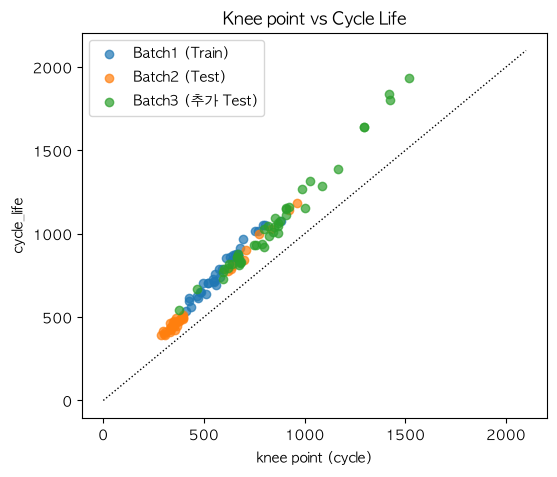

In [66]:
# Knee point: 두 직선으로 나눴을 때 오차가 가장 작은 분기점 (piecewise linear)
def knee_point(g, step=5):
    g = g.sort_values('cycle')
    x = g['cycle'].values
    y = g['QDischarge'].rolling(15, center=True, min_periods=1).median().values
    best, best_sse = np.nan, np.inf
    for k in range(20, len(x) - 20, step):
        sse = 0
        for xs, ys in [(x[:k], y[:k]), (x[k:], y[k:])]:
            coef = np.polyfit(xs, ys, 1)
            sse += ((np.polyval(coef, xs) - ys) ** 2).sum()
        if sse < best_sse:
            best, best_sse = x[k], sse
    return best

knee = pd.Series({cid: knee_point(g) for b in BATCHES for cid, g in summ[b].groupby('cell_id')}, name='knee')
feat['knee'] = knee
feat['knee_frac'] = feat['knee'] / feat['cycle_life']
print('knee / 수명 비율 중앙값:', feat['knee_frac'].median().round(2))
print('knee와 수명 상관:', feat[['knee', 'cycle_life']].corr().iloc[0, 1].round(3))

fig, ax = plt.subplots(figsize=(6, 5))
for b in BATCHES:
    d = feat[feat['batch'] == b]
    ax.scatter(d['knee'], d['cycle_life'], label=BATCH_LABEL[b], alpha=0.7)
lim = [0, 2100]
ax.plot(lim, lim, 'k:', lw=1)
ax.set(title='Knee point vs Cycle Life', xlabel='knee point (cycle)', ylabel='cycle_life')
ax.legend()
fig.savefig(FIG_DIR / 'q2_knee_vs_life.png', dpi=150, bbox_inches='tight')
plt.show()

**해석 (초안):**
- 열화는 일정하지 않고 **가속**된다. 수명 마지막 10% 구간의 감소 속도가 10~20% 구간보다 중앙값 약 21배 빠름
- Knee point는 수명의 약 78% 지점에서 나타나고, knee와 수명의 상관은 0.99
- 즉 knee가 수명을 거의 결정하지만, knee는 사이클 수백 이후에 나타나므로 **100사이클 시점에서는 직접 관측할 수 없음**

**시사점:**
- 초기 100사이클의 용량 숫자(거의 평평한 구간)로 수명을 직선 외삽하면 크게 틀림
- knee 이전에 나타나는 미세 신호(ΔQ(V))가 필요

## Q3. ΔQ(V) 곡선 — 초기 사이클에서 차이가 보이는가?

- ΔQ(V) = Q₁₀₀(V) − Q₁₀(V)
- 전압 축은 3.5V → 2.0V를 1,000개로 나눈 격자로 가정 (원 논문 기준, Vdlin으로 확인 필요)

/var/folders/gd/rq5fqwg90qdcxcjh3r63bs3c0000gn/T/ipykernel_95571/1840164511.py:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.savefig(FIG_DIR / 'q3_delta_q_curves.png', dpi=150, bbox_inches='tight')
/Users/byunhyunjun/workspace/data-analytics-project/ess-battery-life-prediction/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


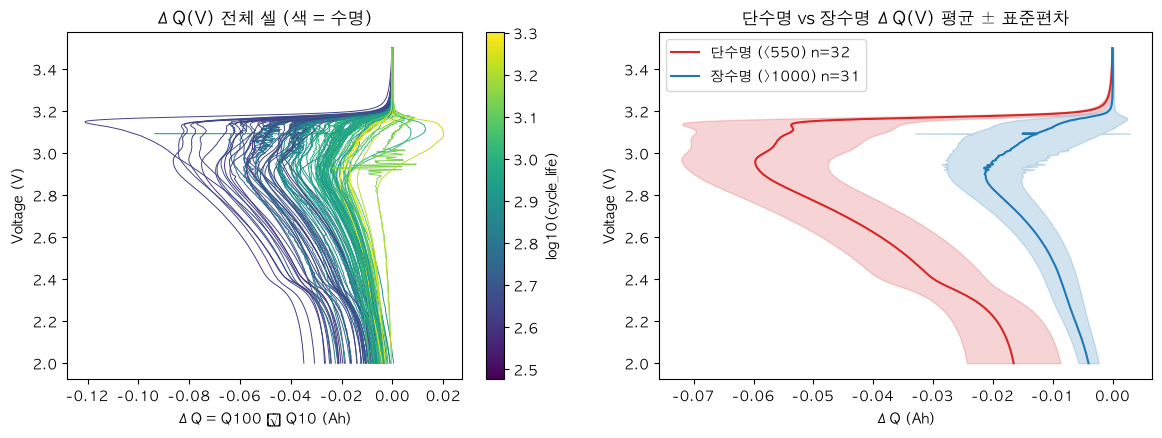

In [67]:
V = np.linspace(3.5, 2.0, 1000)
dq_curves = {cid: d[100] - d[10] for b in BATCHES for cid, d in qdlin[b].items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for cid, dq in dq_curves.items():
    axes[0].plot(dq, V, lw=0.7, color=plt.cm.viridis(norm(feat.loc[cid, 'log_cycle_life'])))
axes[0].set(title='ΔQ(V) 전체 셀 (색 = 수명)', xlabel='ΔQ = Q100 − Q10 (Ah)', ylabel='Voltage (V)')
fig.colorbar(sm, ax=axes[0], label='log10(cycle_life)')

groups = {'단수명 (<550)': feat['cycle_life'] < 550, '장수명 (>1000)': feat['cycle_life'] > 1000}
for (name, mask), color in zip(groups.items(), ['tab:red', 'tab:blue']):
    arr = np.vstack([dq_curves[c] for c in feat.index[mask]])
    m, s = arr.mean(0), arr.std(0)
    axes[1].plot(m, V, color=color, label=f'{name} n={mask.sum()}')
    axes[1].fill_betweenx(V, m - s, m + s, color=color, alpha=0.2)
axes[1].set(title='단수명 vs 장수명 ΔQ(V) 평균 ± 표준편차', xlabel='ΔQ (Ah)', ylabel='Voltage (V)')
axes[1].legend()
fig.savefig(FIG_DIR / 'q3_delta_q_curves.png', dpi=150, bbox_inches='tight')
plt.show()

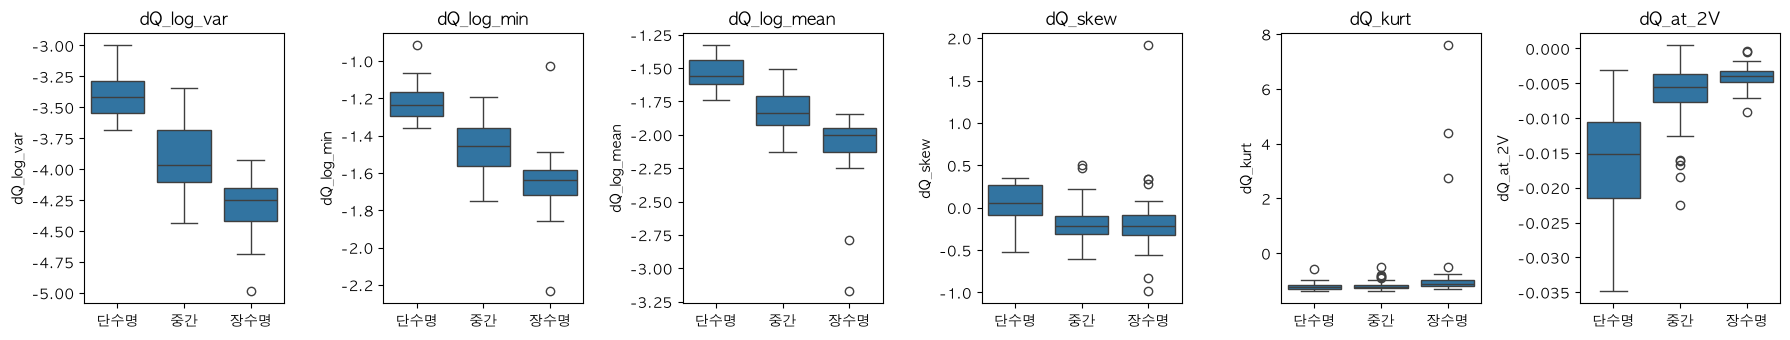

,dQ_log_var,dQ_log_min,dQ_log_mean,dQ_skew,dQ_kurt,dQ_at_2V
life_group,,,,,,
단수명,-3.415,-1.237,-1.559,0.051,-1.232,-0.015
장수명,-4.249,-1.637,-2.001,-0.214,-1.117,-0.004
중간,-3.966,-1.456,-1.835,-0.213,-1.240,-0.006


In [68]:
# 그룹별 ΔQ 통계 피처 분포
feat['life_group'] = np.select([feat['cycle_life'] < 550, feat['cycle_life'] > 1000], ['단수명', '장수명'], '중간')
dq_cols = ['dQ_log_var', 'dQ_log_min', 'dQ_log_mean', 'dQ_skew', 'dQ_kurt', 'dQ_at_2V']
fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))
for ax, c in zip(axes, dq_cols):
    sns.boxplot(data=feat, x='life_group', y=c, order=['단수명', '중간', '장수명'], ax=ax)
    ax.set(title=c, xlabel='')
fig.tight_layout()
fig.savefig(FIG_DIR / 'q3_dq_features_by_group.png', dpi=150, bbox_inches='tight')
plt.show()
feat.groupby('life_group')[dq_cols].median().round(3)

**해석 (초안):**
- 사이클 100과 10의 방전 곡선 차이가 **단수명 셀에서 훨씬 크게(더 음수로) 벌어짐**, 특히 3.0V 부근
- `dQ_log_var` 중앙값: 단수명 −3.42 / 중간 −3.97 / 장수명 −4.25 → 그룹이 뚜렷이 분리
- `dQ_skew`, `dQ_kurt`는 그룹 간 차이가 작음
- 일부 셀 곡선에 3.1V·2.9V 부근 수평 튐(측정 노이즈)이 있음

**시사점:**
- 초기 용량 숫자로는 안 보이던 차이가 곡선 전체에서는 보임 → ΔQ 분산(`dQ_log_var`)을 핵심 피처로 사용
- 왜도·첨도는 노이즈에 민감하므로 보조 피처로만

## Q4. 충전 조건(C-rate)과 수명의 관계는?

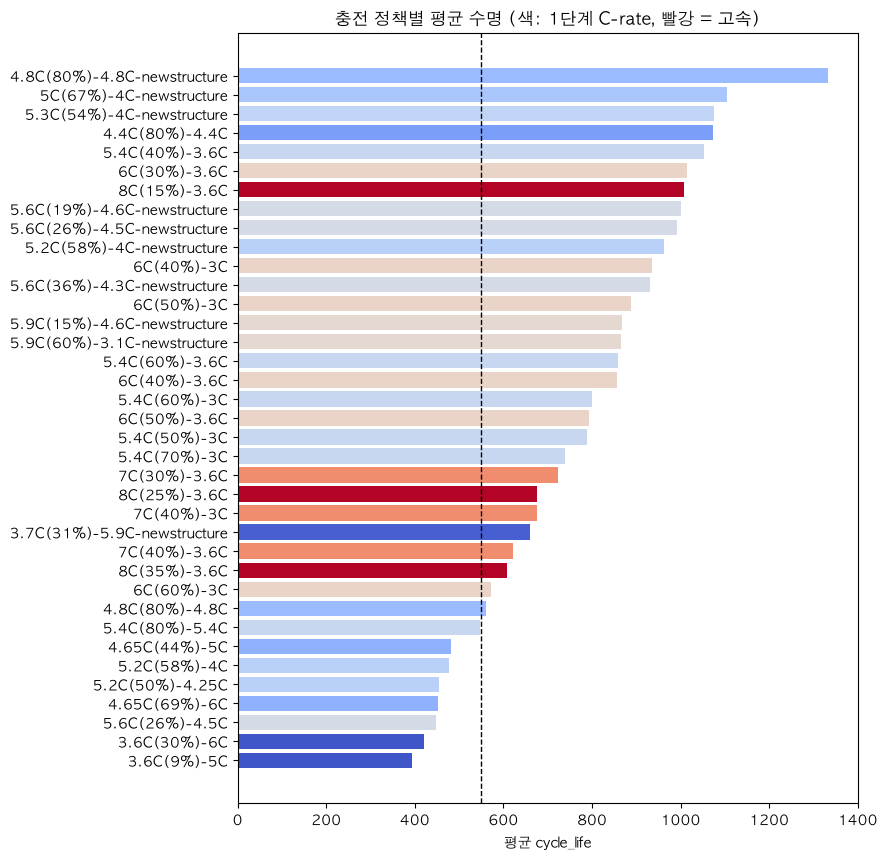

,n,life_mean,C1,chargetime,batches
policy,,,,,
3.6C(9%)-5C,2,394.5,3.6,10.2,b2
3.6C(30%)-6C,2,421.0,3.6,10.2,b2
5.6C(26%)-4.5C,6,448.5,5.6,10.2,b2
4.65C(69%)-6C,2,452.0,4.6,10.2,b2
5.2C(50%)-4.25C,5,454.0,5.2,10.2,b2
5.2C(58%)-4C,4,477.8,5.2,10.2,b2
4.65C(44%)-5C,2,482.5,4.6,10.2,b2
5.4C(80%)-5.4C,2,546.5,5.4,9.0,b1
4.8C(80%)-4.8C,7,560.6,4.8,10.1,"b1,b2"


In [69]:
by_policy = (feat.groupby('policy')
             .agg(n=('cycle_life', 'size'), life_mean=('cycle_life', 'mean'), C1=('C1', 'first'),
                  chargetime=('chargetime_mean_5', 'mean'), batches=('batch', lambda s: ','.join(sorted(set(s)))))
             .sort_values('life_mean'))
fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(by_policy.index, by_policy['life_mean'], color=plt.cm.coolwarm(plt.Normalize(3.5, 8)(by_policy['C1'])))
ax.axvline(550, color='k', ls='--', lw=1)
ax.set(title='충전 정책별 평균 수명 (색: 1단계 C-rate, 빨강 = 고속)', xlabel='평균 cycle_life')
fig.savefig(FIG_DIR / 'q4_life_by_policy.png', dpi=150, bbox_inches='tight')
plt.show()
by_policy.round(1)

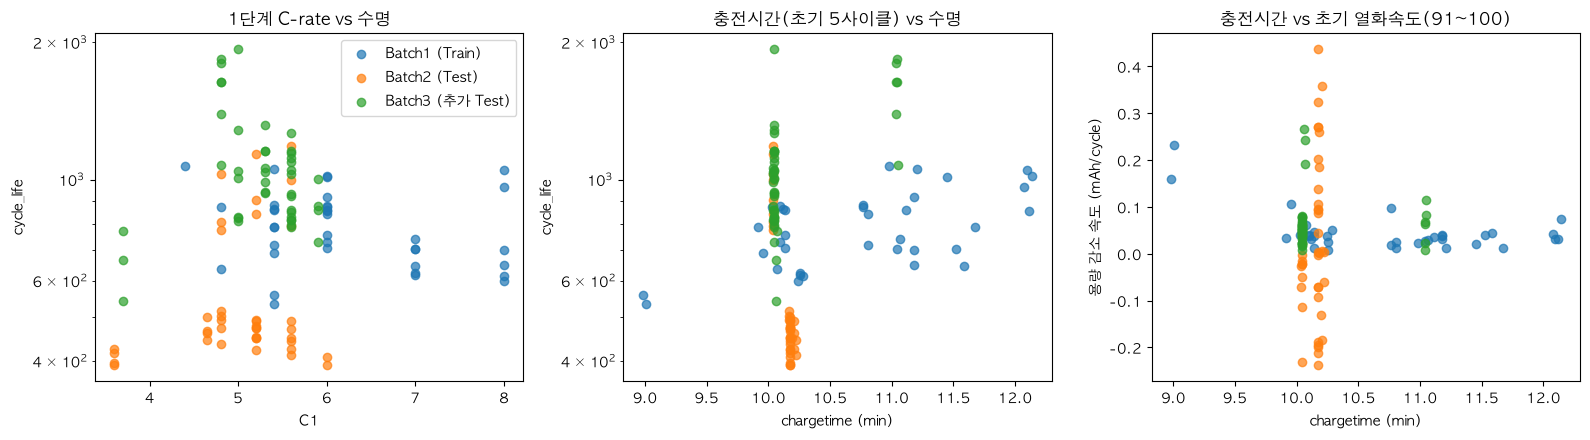

배치별 log 수명과의 상관 (Spearman):


,b1,b2,b3
C1,-0.24,0.06,-0.23
switch_soc,-0.06,0.29,0.44
C2,-0.16,-0.12,0.02
chargetime_mean_5,0.43,-0.79,0.24


In [70]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for b in BATCHES:
    d = feat[feat['batch'] == b]
    axes[0].scatter(d['C1'], d['cycle_life'], label=BATCH_LABEL[b], alpha=0.7)
    axes[1].scatter(d['chargetime_mean_5'], d['cycle_life'], alpha=0.7)
    axes[2].scatter(d['chargetime_mean_5'], -d['QD_slope_91_100'] * 1000, alpha=0.7)
axes[0].set(title='1단계 C-rate vs 수명', xlabel='C1', ylabel='cycle_life', yscale='log')
axes[1].set(title='충전시간(초기 5사이클) vs 수명', xlabel='chargetime (min)', ylabel='cycle_life', yscale='log')
axes[2].set(title='충전시간 vs 초기 열화속도(91~100)', xlabel='chargetime (min)', ylabel='용량 감소 속도 (mAh/cycle)')
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'q4_crate_vs_life.png', dpi=150, bbox_inches='tight')
plt.show()

cr = ['C1', 'switch_soc', 'C2', 'chargetime_mean_5']
print('배치별 log 수명과의 상관 (Spearman):')
pd.DataFrame({b: feat[feat['batch'] == b][cr + ['log_cycle_life']].corr('spearman')['log_cycle_life'][cr]
              for b in BATCHES}).round(2)

In [71]:
# 열화 속도(수명 전체 평균)와 충전 조건 상관
feat['avg_fade_rate'] = (feat.index.map(lambda c: prof.loc[c].mean()) * 1000)
print('평균 열화속도(mAh/cycle)와의 상관 (Spearman, 전체):')
feat[cr + ['avg_fade_rate']].corr('spearman')['avg_fade_rate'][cr].round(2)

평균 열화속도(mAh/cycle)와의 상관 (Spearman, 전체):


C1                  -0.06
switch_soc          -0.07
C2                   0.11
chargetime_mean_5    0.22
Name: avg_fade_rate, dtype: float64

**해석 (초안):**
- "고속 충전 = 단수명"은 **Batch1 안에서만 부분적으로 성립**: 충전시간이 가장 짧은 5.4C(80%) 셀이 최단수명
- 1단계 C-rate(C1) 단독과 log 수명의 상관은 약함 (Batch1 −0.24, Batch2 0.06, Batch3 −0.23)
- 충전시간 상관은 배치마다 **부호가 뒤집힘**(Batch1 +0.57, Batch2 −0.94, Batch3 +0.60)
  - Batch2는 충전시간이 10.04~10.22분으로 거의 같아(표준편차 0.06), 이 상관은 newstructure 여부를 대신 반영한 것으로 보임
- Batch2의 일반 셀은 3.6C처럼 느린 1단계 충전이어도 모두 단수명 → 충전 정책보다 **배치/실험 조건 차이**가 더 큼
- 평균 열화속도와 충전 조건의 상관도 약함(|ρ| ≤ 0.22)

**시사점:**
- 충전 조건 피처는 배치가 바뀌면 관계가 바뀌므로 Test 일반화에 위험 → 규제(ElasticNet)로 영향 제한, 해석 시 주의
- 수명 차이는 충전 정책 이름보다 셀의 실제 열화 반응(ΔQ)으로 포착해야 함

## Q5. 상관관계 — 어떤 신호가 수명과 연관되어 있는가?

- Train(Batch1)으로 판단하고, Test 배치에서도 유지되는지 비교

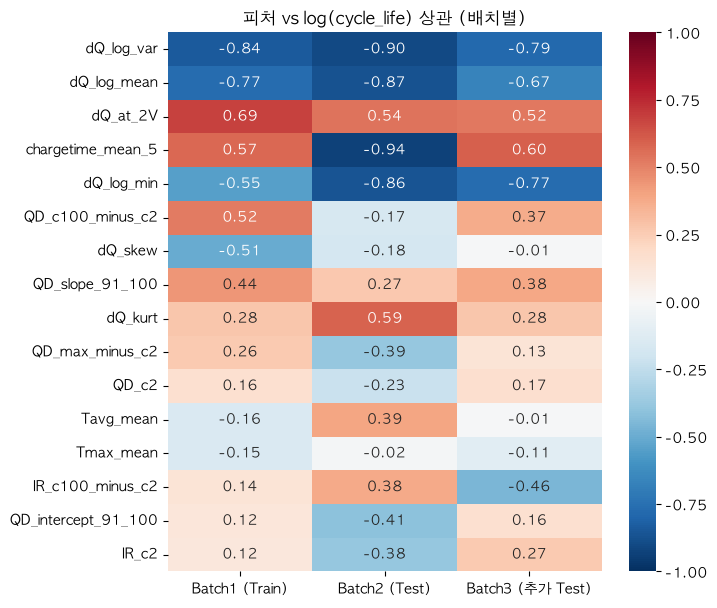

In [72]:
X_cols = ['QD_c2', 'QD_max_minus_c2', 'QD_c100_minus_c2', 'QD_slope_91_100', 'QD_intercept_91_100',
          'IR_c2', 'IR_c100_minus_c2', 'Tmax_mean', 'Tavg_mean', 'chargetime_mean_5',
          'dQ_log_var', 'dQ_log_min', 'dQ_log_mean', 'dQ_skew', 'dQ_kurt', 'dQ_at_2V']
corr_tbl = pd.DataFrame({BATCH_LABEL[b]: feat[feat['batch'] == b][X_cols + ['log_cycle_life']]
                         .corr()['log_cycle_life'][X_cols] for b in BATCHES})
corr_tbl = corr_tbl.reindex(corr_tbl.iloc[:, 0].abs().sort_values(ascending=False).index)
fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(corr_tbl, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('피처 vs log(cycle_life) 상관 (배치별)')
fig.savefig(FIG_DIR / 'q5_corr_with_life.png', dpi=150, bbox_inches='tight')
plt.show()

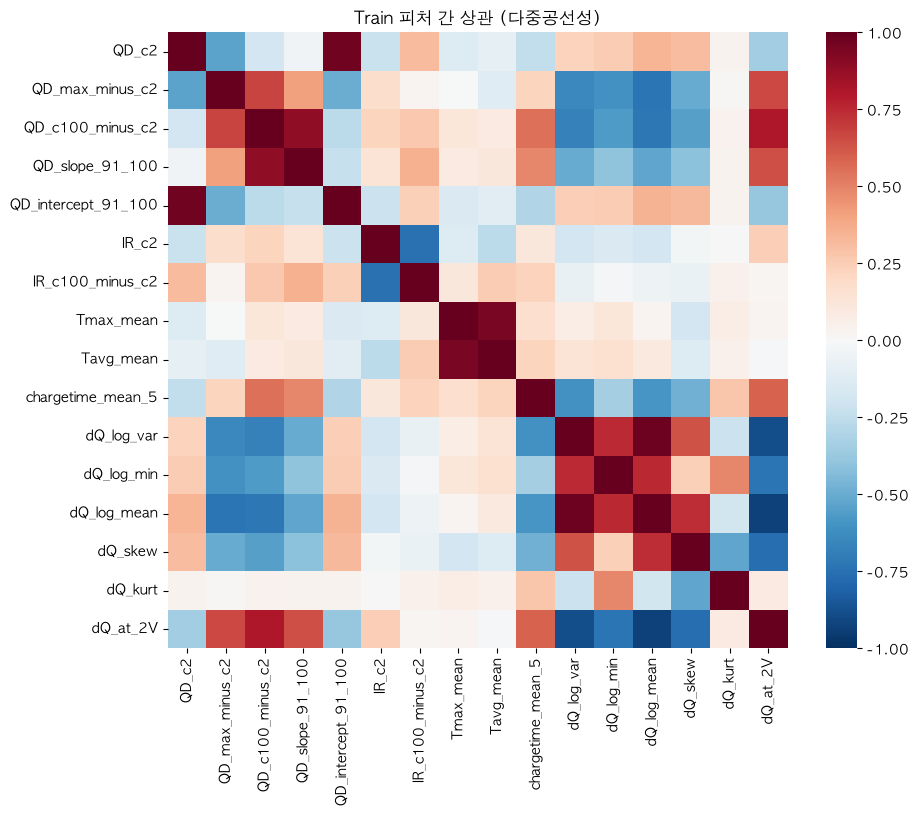

상관 |r| > 0.8 피처 쌍:


dQ_log_var        dQ_log_mean            0.98
QD_c2             QD_intercept_91_100    0.97
Tmax_mean         Tavg_mean              0.95
dQ_log_mean       dQ_at_2V               0.94
QD_c100_minus_c2  QD_slope_91_100        0.89
dQ_log_var        dQ_at_2V               0.88
QD_c100_minus_c2  dQ_at_2V               0.81
dtype: float64

VIF (10 이상이면 다중공선성 의심):


QD_c2                  19996.1
QD_intercept_91_100    19212.6
QD_slope_91_100         4688.8
QD_c100_minus_c2        2102.5
dQ_log_min              1207.4
dQ_log_mean             1048.7
dQ_log_var               823.7
dQ_kurt                  582.4
dQ_skew                   61.0
dQ_at_2V                  53.6
QD_max_minus_c2           46.9
Tavg_mean                 29.1
Tmax_mean                 25.3
IR_c100_minus_c2          10.2
IR_c2                      9.0
chargetime_mean_5          5.0
dtype: float64

In [73]:
# 다중공선성: 피처끼리 상관 + VIF (Train 기준)
Xtr = feat[feat['batch'] == 'b1'][X_cols]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(Xtr.corr(), cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Train 피처 간 상관 (다중공선성)')
fig.savefig(FIG_DIR / 'q5_feature_corr.png', dpi=150, bbox_inches='tight')
plt.show()

def vif(X):
    X = (X - X.mean()) / X.std()
    out = {}
    for c in X.columns:
        others = X.drop(columns=c)
        r2 = LinearRegression().fit(others, X[c]).score(others, X[c])
        out[c] = 1 / (1 - r2) if r2 < 1 else np.inf
    return pd.Series(out).sort_values(ascending=False)

pairs = (Xtr.corr().abs().where(np.triu(np.ones((len(X_cols),) * 2), 1).astype(bool))
         .stack().sort_values(ascending=False))
print('상관 |r| > 0.8 피처 쌍:')
display(pairs[pairs > 0.8].round(2))
print('VIF (10 이상이면 다중공선성 의심):')
vif(Xtr).round(1)

**해석 (초안):**
- 가장 강하고 **배치가 바뀌어도 일관된** 신호는 `dQ_log_var` (Batch1 −0.84 / Batch2 −0.90 / Batch3 −0.79)
- `dQ_log_mean`, `dQ_log_min`도 세 배치 모두 음의 상관
- 온도·내부저항·초기 용량 피처는 약하고 배치마다 부호가 바뀜
- 다중공선성 심각: `dQ_log_var`–`dQ_log_mean` 0.98, `QD_c2`–`QD_intercept_91_100` 0.97, `Tmax`–`Tavg` 0.95, VIF 최대 수만

**시사점:**
- 일반 선형회귀는 계수가 불안정 → L1+L2 규제인 **ElasticNet** 사용 (L1이 중복 피처를 정리)
- 피처 선택 기준: Train 상관 크기 + **배치 간 부호 일관성**